In [ ]:
"""
Author: Ruby Lieber 
Affiliation: University of Bristol
Date: 23/07/2025

Description:
This notebook demonstrates the bias correctiona and downscaling process of DAMIP temperature data for three models (CanESM5, GFDL-CM4, and MRI-ESM2-0). 
Supplementary Figure 1 in "Heat-related mortality attributable to human-induced climate change: findings from the 100 Million Brazilian Cohort". 
"""

In [1]:
# Imports 
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FixedLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import seaborn as sns
from scipy.stats import ks_2samp
import functions as func
from matplotlib.patches import FancyArrowPatch

In [2]:
# Read in Data 
tas_obs = xr.open_dataarray("/user/work/nh25161/obs_padded_interp_01x01_2000_2018.nc")

tas_can_og = xr.open_dataarray("/bp1/geog-tropical/data/BREATHE/processed_damip_data/tas_CanESM5_historical_r1i1p1f1_v20190429_2000-2018.nc")
tas_gfdl_og = xr.open_dataarray("/bp1/geog-tropical/data/BREATHE/processed_damip_data/tas_GFDL-CM4_historical_r1i1p1f1_v20180701_2000-2018.nc")
tas_mri_og = xr.open_dataarray("/bp1/geog-tropical/data/BREATHE/processed_damip_data/tas_MRI-ESM2-0_historical_r1i1p1f1_v20190603_2000-2018.nc")

tas_can_bias = xr.open_dataarray("/bp1/geog-tropical/data/BREATHE/bias_correct_damip/tas_CanESM5_historical_r1i1p1f1_bias_corrected_2000_2018.nc")
tas_gfdl_bias = xr.open_dataarray("/bp1/geog-tropical/data/BREATHE/bias_correct_damip/tas_GFDL-CM4_historical_r1i1p1f1_bias_corrected_2000_2018.nc")
tas_mri_bias = xr.open_dataarray("/bp1/geog-tropical/data/BREATHE/bias_correct_damip/tas_MRI-ESM2-0_historical_r1i1p1f1_bias_corrected_2000_2018.nc")

tas_can_down = xr.open_dataarray("/bp1/geog-tropical/data/BREATHE/downscale_damip_05_mask/tas_CanESM5_historical_r1i1p1f1_downscaled_05_masked_2000_2018.nc")
tas_gfdl_down = xr.open_dataarray("/bp1/geog-tropical/data/BREATHE/downscale_damip_05_mask/tas_GFDL-CM4_historical_r1i1p1f1_downscaled_05_masked_2000_2018.nc")
tas_mri_down = xr.open_dataarray("/bp1/geog-tropical/data/BREATHE/downscale_damip_05_mask/tas_MRI-ESM2-0_historical_r1i1p1f1_downscaled_05_masked_2000_2018.nc")

can_gfdl_mask =  xr.open_dataarray("/bp1/geog-tropical/data/BREATHE/bias_correct_damip/CanESM5_GFDL_mask_2x2.nc")
mri_mask =  xr.open_dataarray("/bp1/geog-tropical/data/BREATHE/bias_correct_damip/MRI-ESM2_mask_1x1.nc")
obs_mask = xr.open_dataarray("/user/work/nh25161/brazil_mask_01x01.nc")

In [3]:
# Select Brazil
tas_can_og = func.process_tas_model_data(tas_can_og, tas_obs).isel(lat=slice(1,21)).isel(lon=slice(1,21))
tas_gfdl_og = func.process_tas_model_data(tas_gfdl_og, tas_obs).isel(lat=slice(1,21)).isel(lon=slice(1,21))
tas_mri_og = func.process_tas_model_data(tas_mri_og, tas_obs).isel(lat=slice(1,42)).isel(lon=slice(1,42))
# Mask model
tas_can_og = tas_can_og.assign_coords(lat=can_gfdl_mask.lat, lon=can_gfdl_mask.lon)
tas_can_og = tas_can_og.where(~np.isnan(can_gfdl_mask))
tas_gfdl_og = tas_gfdl_og.assign_coords(lat=can_gfdl_mask.lat, lon=can_gfdl_mask.lon)
tas_gfdl_og = tas_gfdl_og.where(~np.isnan(can_gfdl_mask))
tas_mri_og = tas_mri_og.assign_coords(lat=mri_mask.lat, lon=mri_mask.lon)
tas_mri_og = tas_mri_og.where(~np.isnan(mri_mask))
# Mask bias corrected
tas_can_bias = tas_can_bias.isel(lat=slice(1,21)).isel(lon=slice(1,21)).assign_coords(lat=can_gfdl_mask.lat, lon=can_gfdl_mask.lon)
tas_can_bias = tas_can_bias.where(~np.isnan(can_gfdl_mask))
tas_gfdl_bias = tas_gfdl_bias.isel(lat=slice(1,21)).isel(lon=slice(1,21)).assign_coords(lat=can_gfdl_mask.lat, lon=can_gfdl_mask.lon)
tas_gfdl_bias = tas_gfdl_bias.where(~np.isnan(can_gfdl_mask))
tas_mri_bias = tas_mri_bias.isel(lat=slice(1,42)).isel(lon=slice(1,42)).assign_coords(lat=mri_mask.lat, lon=mri_mask.lon)
tas_mri_bias = tas_mri_bias.where(~np.isnan(mri_mask))
# Mask obs
tas_obs = tas_obs.where(~np.isnan(obs_mask))

Longitudes in 'lon' shifted to [-180, 180] range.
Longitudes in 'lon' shifted to [-180, 180] range.
Longitudes in 'lon' shifted to [-180, 180] range.


In [4]:
# KS test
def calculate_ks(data1, data2):
    data1 = data1.values.flatten()
    data2 = data2.values.flatten()
    test_stat, p_value = ks_2samp(data1[~np.isnan(data1)], data2[~np.isnan(data2)])
    return test_stat, p_value

test_stat_can, p_value_can = calculate_ks(tas_can_down, tas_obs)
test_stat_gfdl, p_value_gfdl = calculate_ks(tas_gfdl_down, tas_obs)
test_stat_mri, p_value_mri = calculate_ks(tas_mri_down, tas_obs)

In [5]:
# Plotting things
titles = ["a. CanESM5 2° x 2°", "b. GFDL-CM4 2° x 2°", "c. MRI-ESM2-0 2° x 2°",
          "d. Bias Corrected 2° x 2°", "e. Bias Corrected 2° x 2°", "f. Bias Corrected 1° x 1°",
          "g. Downscaled 0.5° x 0.5°", "h. Downscaled 0.5° x 0.5°", "i. Downscaled 0.5° x 0.5°",
          "j. BR_DWGD Observations 0.1° x 0.1°"]

datasets = [
    tas_can_og, tas_gfdl_og, tas_mri_og,
    tas_can_bias, tas_gfdl_bias, tas_mri_bias,
    tas_can_down, tas_gfdl_down, tas_mri_down,
]

def format_gridlines(ax, top_labels=False, bottom_labels=False, left_labels=False, right_labels=False):
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.75, color='gray', alpha=0.5, linestyle='--')

    # Set fixed intervals for longitude and latitude gridlines
    gl.xlocator = FixedLocator(np.arange(-80, -30+1, 10))  # Adjust to your longitude range and step
    gl.ylocator = FixedLocator(np.arange(-40, 10+1, 10))   # Adjust to your latitude range and step
    gl.top_labels = top_labels
    gl.bottom_labels = bottom_labels
    gl.right_labels = right_labels
    gl.left_labels = left_labels
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

def plot_brazil_tas(ax, data, left_labels=True, bottom_labels=False):
    im = data.mean(dim='time').plot(ax=ax, cmap='RdBu_r', vmin=vmin, vmax=vmax,
                                    add_colorbar=False, transform=ccrs.PlateCarree())
    format_gridlines(ax, left_labels=left_labels, bottom_labels=bottom_labels)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    return im

def plot_tas_pdfs(ax):

    # Clean flattening function
    def flatten_clean(xr_data):
        arr = xr_data.values  # Convert to numpy array
        arr = arr.flatten()   # Flatten to 1D
        return arr[~np.isnan(arr)]  # Remove NaNs

    # Flatten datasets
    obs_vals = flatten_clean(tas_obs)
    can_vals = flatten_clean(tas_can_down)
    gfdl_vals = flatten_clean(tas_gfdl_down)
    mri_vals = flatten_clean(tas_mri_down)

    # Plot
    sns.set(style="whitegrid")

    # Plot histograms
    ax.hist(obs_vals,  bins=50, density=True, alpha=0.6, color="#87CEEB",  label="Observations")
    ax.hist(can_vals,  bins=50, density=True, alpha=0.6, color="#FF7F50",  label="CanESM5 Downscaled")
    ax.hist(gfdl_vals, bins=50, density=True, alpha=0.6, color="#2ca25f",  label="GFDL Downscaled")
    ax.hist(mri_vals,  bins=50, density=True, alpha=0.6, color="#88419d",  label="MRI Downscaled")

    # Labels and legend
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Density")
    ax.set_title("k. Daily Mean Temperature Distribution")

    # Add legend in top left
    legend = ax.legend(loc='upper left', frameon=True)

    # Add annotation below legend
    textstr = '\n'.join((
        f"CanESM5: KS={test_stat_can:.2f}, p={p_value_can:.2f}",
        f"GFDL:    KS={test_stat_gfdl:.2f}, p={p_value_gfdl:.2f}",
        f"MRI:     KS={test_stat_mri:.2f}, p={p_value_mri:.2f}",
    ));
    # Slight offset below the legend
    ax.text(0.05, 0.40, textstr, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.7))
    
    # Set y-axis ticks only
    ax.set_yticks([0.05, 0.10, 0.15, 0.20])
    ax.set_yticklabels([f"{val:.2f}" for val in [0.05, 0.10, 0.15, 0.20]])

    # Light horizontal gridlines only
    ax.grid(True, axis='y', linestyle='--', linewidth=0.6, alpha=0.5)
    ax.grid(True, axis='x', linestyle='--', linewidth=0.6, alpha=0.5)

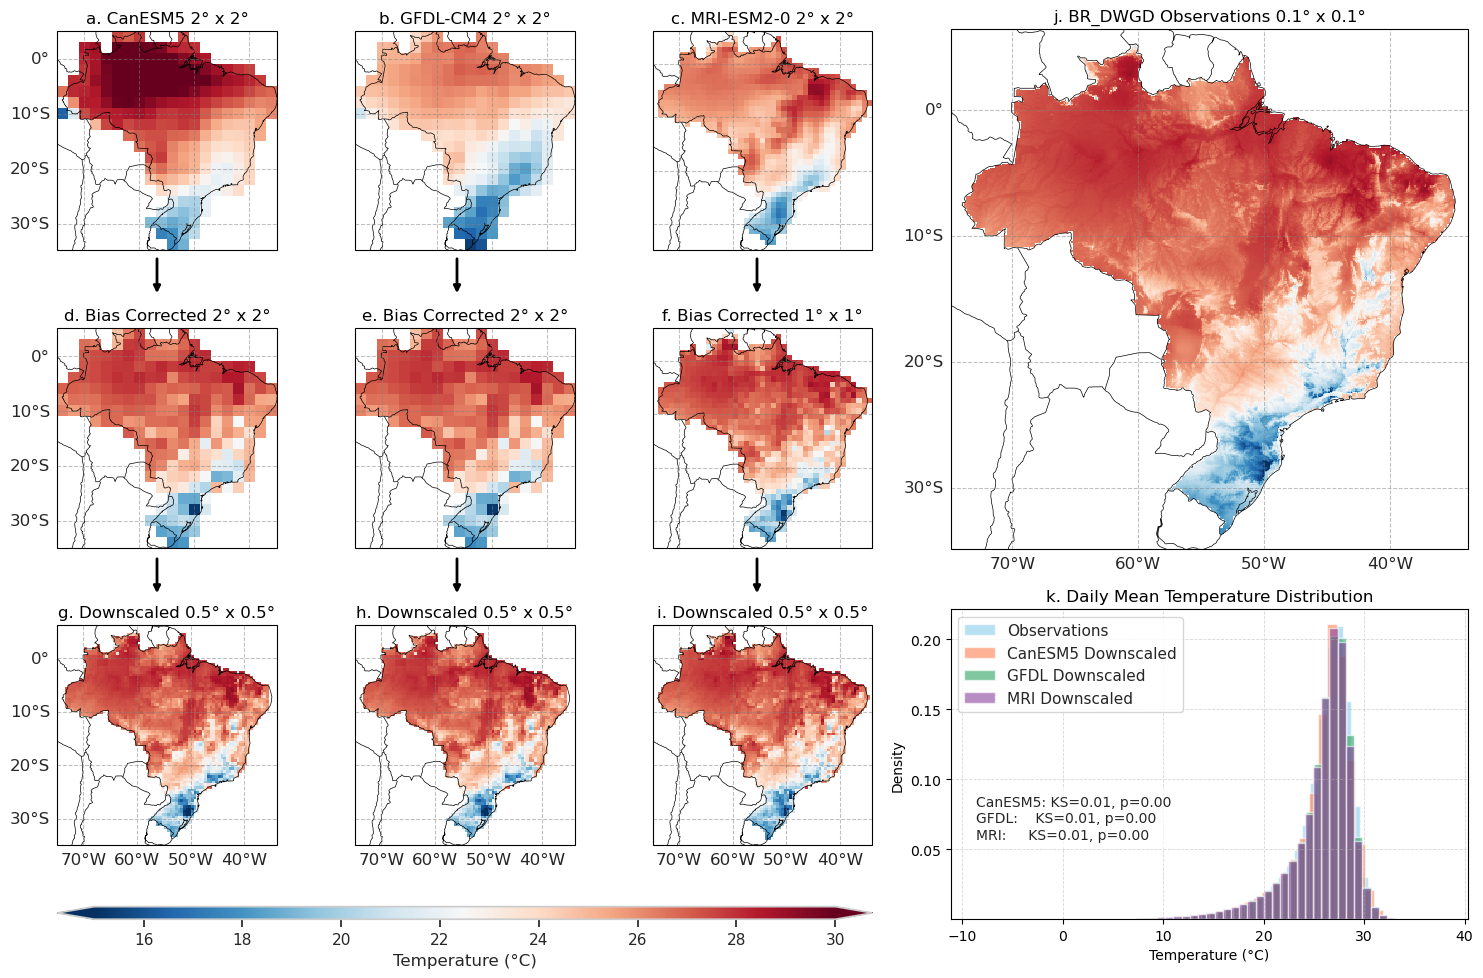

In [6]:
fig = plt.figure(figsize=(15, 10))
gs = GridSpec(4, 5, figure=fig, height_ratios=[1, 1, 1, 0.05])

vmin = 15
vmax = 30

# Panels 1-9
axes = []
for idx, (row, col) in enumerate([(i, j) for i in range(3) for j in range(3)]):
    ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())
    left = (col == 0)
    bottom = (row == 2)
    im = plot_brazil_tas(ax, datasets[idx], left_labels=left, bottom_labels=bottom)
    axes.append(ax)

# Panels 10 and 11 
ax10 = fig.add_subplot(gs[0:2, 3:5], projection=ccrs.PlateCarree())
im = plot_brazil_tas(ax10, tas_obs, left_labels=True, bottom_labels=True)
axes.append(ax10)
ax11 = fig.add_subplot(gs[2:4, 3:5])
plot_tas_pdfs(ax11)

for ax, title in zip(axes, titles):
    ax.set_title(title)

arrow_positions = [
    ((0.11, 0.73), (0.11, 0.69)),  # between subplot 1 and 4
    ((0.31, 0.73), (0.31, 0.69)),  # between subplot 2 and 5
    ((0.51, 0.73), (0.51, 0.69)),  # between subplot 3 and 6
    ((0.11, 0.43), (0.11, 0.39)),  # between subplot 4 and 7
    ((0.31, 0.43), (0.31, 0.39)),  # between subplot 5 and 8
    ((0.51, 0.43), (0.51, 0.39)),  # between subplot 6 and 9
]

for start, end in arrow_positions:
    arrow = FancyArrowPatch(start, end, transform=fig.transFigure,
                            arrowstyle='-|>', color='black', linewidth=2, mutation_scale=10)
    fig.add_artist(arrow)

cax = fig.add_subplot(gs[3, 0:3])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', extend='both')
cbar.set_label("Temperature (°C)")

plt.tight_layout()